In [1]:
import cv2
import mediapipe as mp
import numpy as np
import os
from tqdm import tqdm

# --- 1. Setup MediaPipe Holistic Model ---
mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils

def mediapipe_detection(image, model):
    """Processes an image with the MediaPipe Holistic model."""
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image.flags.writeable = False
    results = model.process(image)
    image.flags.writeable = True
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    return image, results

def draw_styled_landmarks(image, results):
    """Draws ONLY the hand landmarks."""
    # Draw left hand connections
    if results.left_hand_landmarks:
        mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                                 mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                                 mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)) 
    # Draw right hand connections
    if results.right_hand_landmarks:  
        mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                                 mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                                 mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)) 

def extract_keypoints(results):
    """
    Extracts keypoints and concatenates them.
    Extracts Left Hand (21*3) + Right Hand (21*3) = 126 features
    """
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() \
        if results.left_hand_landmarks else np.zeros(21 * 3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() \
        if results.right_hand_landmarks else np.zeros(21 * 3)
    return np.concatenate([lh, rh])

# --- 2. Define Paths ---
DATA_PATH = "project_dataset" 
SAVE_PATH = "project_features" # Path to save the new .npy files

actions = [d for d in os.listdir(DATA_PATH) if os.path.isdir(os.path.join(DATA_PATH, d))]

# --- 3. Main Extraction Loop ---
print("Starting NEW feature extraction (Hands-Only)...")
VIDEO_EXTENSIONS = ('.mp4', '.avi', '.mov', '.mkv', '.webm', '.mpeg')

with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    for action in tqdm(actions, desc="Processing Actions"):
        action_data_path = os.path.join(DATA_PATH, action)
        action_save_path = os.path.join(SAVE_PATH, action)
        os.makedirs(action_save_path, exist_ok=True)

        video_files = [f for f in os.listdir(action_data_path) if f.lower().endswith(VIDEO_EXTENSIONS)]
        
        for video_name in video_files:
            video_path = os.path.join(action_data_path, video_name)
            cap = cv2.VideoCapture(video_path)
            video_sequences = []

            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break
                image, results = mediapipe_detection(frame, holistic)
                
                # (Optional) Visualization
                draw_styled_landmarks(image, results)
                cv2.imshow(f'MediaPipe Feed - {action} - {video_name}', image)
                if cv2.waitKey(1) & 0xFF == ord('q'):
                    break

                keypoints = extract_keypoints(results)
                video_sequences.append(keypoints)

            cap.release()
            npy_filename = os.path.splitext(video_name)[0] + '.npy'
            np.save(os.path.join(action_save_path, npy_filename), np.array(video_sequences))

cv2.destroyAllWindows()
print("\nFeature extraction complete! (Hands-Only)")

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Starting NEW feature extraction (Hands-Only)...


Processing Actions: 100%|██████████████████████████████████████| 11/11 [1:20:42<00:00, 440.24s/it]



Feature extraction complete! (Hands-Only)


In [3]:
import numpy as np
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tqdm import tqdm

# --- 1. Define Paths and Parameters ---
SAVE_PATH = "project_features" 
actions = [d for d in os.listdir(SAVE_PATH) if os.path.isdir(os.path.join(SAVE_PATH, d))]
label_map = {label: num for num, label in enumerate(actions)}
print(f"Found {len(actions)} actions: {label_map}")

# --- 2. Set the Sequence Length ---
SEQUENCE_LENGTH = 90
FEATURE_COUNT = 126 # (21*3 Hand + 21*3 Hand)

# --- 3. Load, Pad, and Label the Data ---
sequences, labels = [], []
print("Loading and processing 'Hands-Only' data...")
for action in tqdm(actions, desc="Loading Sequences"):
    action_path = os.path.join(SAVE_PATH, action)
    sequence_files = [f for f in os.listdir(action_path) if f.endswith('.npy')]
    
    for sequence_file in sequence_files:
        res = np.load(os.path.join(action_path, sequence_file))
        padded_res = np.zeros((SEQUENCE_LENGTH, FEATURE_COUNT))
        if len(res) <= SEQUENCE_LENGTH:
            padded_res[:len(res)] = res
        else:
            padded_res = res[:SEQUENCE_LENGTH]
        sequences.append(padded_res)
        labels.append(label_map[action])

# --- 4. Prepare for the Model ---
X = np.array(sequences)
y = np.array(labels) # 1D list of labels (0, 1, 0, 2, 3, etc.)
y_categorical = to_categorical(y).astype(int) # One-hot version

print(f"\nSuccessfully loaded {len(X)} sequences.")
print(f"Data shapes before splitting:")
print(f"X (sequences) shape: {X.shape}")
print(f"y (labels, one-hot) shape: {y_categorical.shape}")

# --- 5. Split into Training and Testing Data ---
# We stratify by 'y' to ensure all 11 classes are fairly represented
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.20, random_state=42, stratify=y)

print("\nData shapes after splitting:")
print(f"X_train shape: {X_train.shape} (This is your new training data!)")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Found 11 actions: {'alright': 0, 'cool': 1, 'good': 2, 'hello': 3, 'job': 4, 'new': 5, 'secretary': 6, 'sorry': 7, 'Team': 8, 'Technology': 9, 'thankyou': 10}
Loading and processing 'Hands-Only' data...


Loading Sequences: 100%|██████████████████████████████████████████| 11/11 [00:16<00:00,  1.53s/it]


Successfully loaded 331 sequences.
Data shapes before splitting:
X (sequences) shape: (331, 90, 126)
y (labels, one-hot) shape: (331, 11)

Data shapes after splitting:
X_train shape: (264, 90, 126) (This is your new training data!)
y_train shape: (264, 11)
X_test shape: (67, 90, 126)
y_test shape: (67, 11)


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import ModelCheckpoint

# --- 1. Define Our Champion Model ---
model_final = Sequential()
# Input shape (90 frames, 126 features)
model_final.add(LSTM(64, return_sequences=True, input_shape=(90, 126)))
model_final.add(LSTM(64, return_sequences=False))
model_final.add(Dense(64, activation='relu'))
# Output layer has 11 units now (for your 11 words)
model_final.add(Dense(len(actions), activation='softmax'))

# --- 2. Compile the Model ---
model_final.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])

model_final.summary()

# --- 3. Create the "Save Best" Callback ---
checkpoint_callback = ModelCheckpoint(
    filepath='best_model_NEW.h5',  # <-- Saved to a new file name
    monitor='val_categorical_accuracy',  # Watch the "closed-book" test score
    mode='max',
    save_best_only=True,
    verbose=1
)

# --- 4. Train the Model ---
print("\n--- Starting Final Model Training (NEW DATA) ---")
# Train for 150 epochs
history_final = model_final.fit(
    X_train, 
    y_train, 
    epochs=150, 
    validation_data=(X_test, y_test),
    callbacks=[checkpoint_callback]
)

print("--- Model Training Complete ---")
print("The best model is saved as 'best_model_NEW.h5'")

D:\SignLanguageProject\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 90, 64)              │          48,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 11)                  │             715 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 86,795 (339.04 KB)

 Trainable params: 86,795 (339.04 KB)

...

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 212ms/step - categorical_accuracy: 0.9621 - loss: 0.2164 - val_categorical_accuracy: 0.8209 - val_loss: 0.6804
Epoch 22/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - categorical_accuracy: 0.9200 - loss: 0.2437
Epoch 22: val_categorical_accuracy did not improve from 0.82090
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 207ms/step - categorical_accuracy: 0.9205 - loss: 0.2551 - val_categorical_accuracy: 0.7463 - val_loss: 0.7614
Epoch 23/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - categorical_accuracy: 0.9475 - loss: 0.2131
Epoch 23: val_categorical_accuracy did not improve from 0.82090
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 195ms/step - categorical_accuracy: 0.9205 - loss: 0.2618 - val_categorical_accuracy: 0.7463 - val_loss: 0.6716
Epoch 24/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - categorical_accuracy: 0.8978 - loss: 0.3208
Epoch 24: val_categorical_accuracy did not improve from 0.82090
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 183ms/step - categorical_accuracy: 0.8939 - loss: 0.3218 - val_catego

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 185ms/step - categorical_accuracy: 0.9053 - loss: 0.3165 - val_categorical_accuracy: 0.8507 - val_loss: 0.4744
Epoch 28/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - categorical_accuracy: 0.9253 - loss: 0.2518
Epoch 28: val_categorical_accuracy did not improve from 0.85075
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 178ms/step - categorical_accuracy: 0.9280 - loss: 0.2621 - val_categorical_accuracy: 0.8060 - val_loss: 0.5480
Epoch 29/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - categorical_accuracy: 0.9343 - loss: 0.2219
Epoch 29: val_categorical_accuracy did not improve from 0.85075
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 181ms/step - categorical_accuracy: 0.9470 - loss: 0.1909 - val_categorical_accuracy: 0.7612 - val_loss: 0.5443
Epoch 30/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - categorical_accuracy: 0.9543 - loss: 0.2020
Epoch 30: val_categorical_accuracy improved from 0.85075 to 0.86567, saving model to best_model_NEW.h5


9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 186ms/step - categorical_accuracy: 0.9583 - loss: 0.1827 - val_categorical_accuracy: 0.8657 - val_loss: 0.4469
Epoch 31/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - categorical_accuracy: 0.9849 - loss: 0.1014
Epoch 31: val_categorical_accuracy improved from 0.86567 to 0.89552, saving model to best_model_NEW.h5


9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 186ms/step - categorical_accuracy: 0.9848 - loss: 0.1137 - val_categorical_accuracy: 0.8955 - val_loss: 0.4049
Epoch 32/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - categorical_accuracy: 0.9811 - loss: 0.0790
Epoch 32: val_categorical_accuracy did not improve from 0.89552
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 175ms/step - categorical_accuracy: 0.9886 - loss: 0.0787 - val_categorical_accuracy: 0.8657 - val_loss: 0.3982
Epoch 33/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - categorical_accuracy: 0.9822 - loss: 0.0816
Epoch 33: val_categorical_accuracy did not improve from 0.89552
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 176ms/step - categorical_accuracy: 0.9773 - loss: 0.0776 - val_categorical_accuracy: 0.8358 - val_loss: 0.4879
Epoch 34/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - categorical_accuracy: 0.9777 - loss: 0.1151
Epoch 34: val_categorical_accuracy did not improve from 0.89552
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 180ms/step - categorical_accuracy: 0.9811 - loss: 0.0911 - val_catego

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 196ms/step - categorical_accuracy: 0.9886 - loss: 0.0647 - val_categorical_accuracy: 0.9104 - val_loss: 0.3572
Epoch 43/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - categorical_accuracy: 0.9893 - loss: 0.0471
Epoch 43: val_categorical_accuracy did not improve from 0.91045
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 173ms/step - categorical_accuracy: 0.9886 - loss: 0.0523 - val_categorical_accuracy: 0.8507 - val_loss: 0.3617
Epoch 44/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - categorical_accuracy: 0.9905 - loss: 0.0421
Epoch 44: val_categorical_accuracy did not improve from 0.91045
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 180ms/step - categorical_accuracy: 0.9886 - loss: 0.0453 - val_categorical_accuracy: 0.8507 - val_loss: 0.3632
Epoch 45/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - categorical_accuracy: 0.9939 - loss: 0.0381
Epoch 45: val_categorical_accuracy did not improve from 0.91045
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 186ms/step - categorical_accuracy: 0.9924 - loss: 0.0403 - val_catego

--- Evaluating 'best_model_NEW.h5' ---
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - categorical_accuracy: 0.9104 - loss: 0.3572

Overall Test Loss: 0.3572
Overall Test Accuracy: 91.04%
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 472ms/step

--- Classification Report (Accuracy for each sign) ---
              precision    recall  f1-score   support

     alright       1.00      0.67      0.80         6
        cool       1.00      1.00      1.00         6
        good       0.86      1.00      0.92         6
       hello       0.71      0.83      0.77         6
         job       1.00      0.67      0.80         6
         new       1.00      1.00      1.00         6
   secretary       1.00      0.83      0.91         6
       sorry       1.00      1.00      1.00         6
        Team       0.70      1.00      0.82         7
  Technology       1.00      1.00      1.00         6
    thankyou       1.00      1.00      1.00         6

    accuracy                           0.91        67
   macro avg       0.

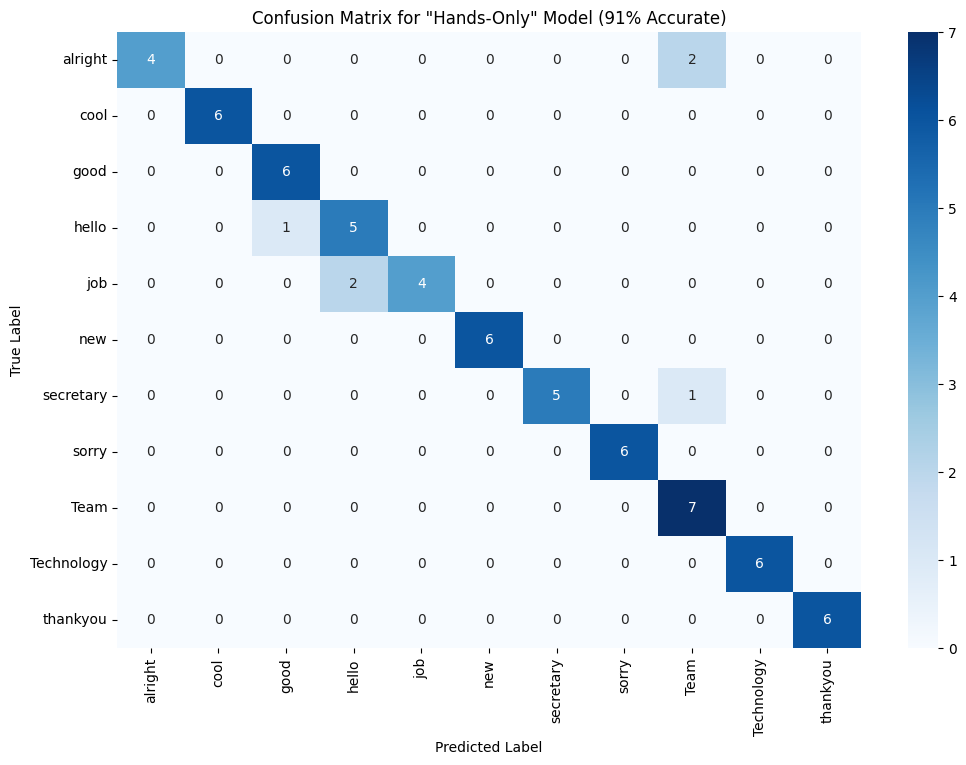

In [5]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Load Model and Data ---
model = tf.keras.models.load_model('best_model_NEW.h5')

# Re-create your 'actions' list
SAVE_PATH = "project_features" 
actions = [d for d in os.listdir(SAVE_PATH) if os.path.isdir(os.path.join(SAVE_PATH, d))]

# --- 2. Evaluate Overall Accuracy ---
print("--- Evaluating 'best_model_NEW.h5' ---")
# Your X_test and y_test should still be in memory
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"\nOverall Test Loss: {test_loss:.4f}")
print(f"Overall Test Accuracy: {test_accuracy * 100:.2f}%") # Should be 91.04%

# --- 3. Get Detailed Predictions ---
y_pred_probs = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# --- 4. Get Per-Class Accuracy (Classification Report) ---
print("\n--- Classification Report (Accuracy for each sign) ---")
print(classification_report(y_true_labels, y_pred_labels, target_names=actions, zero_division=0))

# --- 5. Generate Confusion Matrix ---
print("\n--- Confusion Matrix ---")
conf_matrix = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=actions, yticklabels=actions)
plt.title('Confusion Matrix for "Hands-Only" Model (91% Accurate)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
import cv2
import mediapipe as mp
import numpy as np
import tensorflow as tf
import os # <-- This is the line that fixes your error

# --- 1. Load the "Hands-Only" Model and Labels ---
# The 'WARNING:absl' message is normal, you can ignore it.
model = tf.keras.models.load_model('best_model_NEW.h5')

SAVE_PATH = "project_features" 
actions = [d for d in os.listdir(SAVE_PATH) if os.path.isdir(os.path.join(SAVE_PATH, d))]

print(f"Loaded model 'best_model_NEW.h5' with actions: {actions}")

# --- 2. Setup MediaPipe Holistic Model ---
mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils

def mediapipe_detection(image, model):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image.flags.writeable = False
    results = model.process(image)
    image.flags.writeable = True
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    return image, results

def draw_styled_landmarks(image, results):
    """Draws ONLY the hand landmarks."""
    if results.left_hand_landmarks:
        mp_drawing.draw_landmarks(image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                                 mp_drawing.DrawingSpec(color=(121,22,76), thickness=2, circle_radius=4), 
                                 mp_drawing.DrawingSpec(color=(121,44,250), thickness=2, circle_radius=2)) 
    if results.right_hand_landmarks:  
        mp_drawing.draw_landmarks(image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS, 
                                 mp_drawing.DrawingSpec(color=(245,117,66), thickness=2, circle_radius=4), 
                                 mp_drawing.DrawingSpec(color=(245,66,230), thickness=2, circle_radius=2)) 

def extract_keypoints(results):
    """
    Extracts keypoints for the "Hands-Only" model (126 features)
    """
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() \
        if results.left_hand_landmarks else np.zeros(21 * 3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() \
        if results.right_hand_landmarks else np.zeros(21 * 3)
    return np.concatenate([lh, rh])

# --- 3. Main Real-Time Loop ---
sequence = [] 
# We can be much more confident! Let's set the threshold high.
CONFIDENCE_THRESHOLD = 0.8 # 80%

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Error: Could not open webcam.")
    exit()

with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        image, results = mediapipe_detection(frame, holistic)
        draw_styled_landmarks(image, results)
        
        # 3. Extract keypoints (using the 126-feature function)
        keypoints = extract_keypoints(results)
        sequence.append(keypoints)
        sequence = sequence[-90:] 
        
        # 4. Make a prediction
        if len(sequence) == 90:
            res_probs = model.predict(np.expand_dims(sequence, axis=0))[0]
            predicted_label_index = np.argmax(res_probs) 
            confidence = res_probs[predicted_label_index]
            predicted_word = actions[predicted_label_index]
            
            # 5. Visualization Logic
            if confidence > CONFIDENCE_THRESHOLD:
                text_color = (0, 255, 0) # Green
                display_text = f"{predicted_word} ({confidence*100:.1f}%)"
            else:
                text_color = (0, 0, 255) # Red
                display_text = f"Thinking... {predicted_word} ({confidence*100:.1f}%)"

            # *** I fixed a typo here: cv_FONT_HERSHEY_SIMPLEX -> cv2.FONT_HERSHEY_SIMPLEX ***
            cv2.putText(image, display_text, 
                        (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, text_color, 2, cv2.LINE_AA)

        # 6. Show the webcam feed
        cv2.imshow('OpenCV Feed', image)

        if cv2.waitKey(10) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()

Loaded model 'best_model_NEW.h5' with actions: ['alright', 'cool', 'good', 'hello', 'job', 'new', 'secretary', 'sorry', 'Team', 'Technology', 'thankyou']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━

In [5]:
print(actions)

['alright', 'cool', 'good', 'hello', 'job', 'new', 'secretary', 'sorry', 'Team', 'Technology', 'thankyou']
